In [1]:
import xupy as xp
import matplotlib.pyplot as plt
from numpy.ma import masked_array

from ekarus.e2e.utils.image_utils import image_grid,reshape_on_mask,get_circular_mask


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 4060 Laptop GPU`
       Memory = 7805.56 MB | Compute Capability = 8.9
       Using CuPy 13.5.1 for acceleration.


In [2]:
def define_target_roi(pupil, iwa, owa, oversampling:int, symmetric:bool=False, heightInLambdaOverD=None):
    mask_shape = max(pupil.shape)
    padded_pupil = xp.pad(1-pupil.copy(), pad_width=int((mask_shape*(oversampling-1)//2)), mode='constant', constant_values=0.0)
    X,Y = image_grid(padded_pupil.shape,recenter=True)
    rho = xp.sqrt(X**2+Y**2)
    if symmetric is True:
        where = (rho <= owa*oversampling) * (rho >= iwa*oversampling)
    else:
        where = (rho <= owa*oversampling) * (X >= iwa*oversampling) 
    if heightInLambdaOverD is not None:
        where *= (abs(Y) < heightInLambdaOverD/2*oversampling)
    return where

def get_apodizer_phase(pupil, target_contrast, oversampling:int=4,
                       max_its:int=20, beta:float=0, IF=None):
    N = max(pupil.shape)
    pad_width = N*(oversampling-1)//2
    pad_pupil = xp.pad(pupil, pad_width, mode='constant', constant_values=0.0)
    dark_zone = target_contrast < 0.1

    a = pad_pupil.copy().astype(xp.complex64)
    old_ff = None

    if IF is not None:
        Rec = xp.linalg.pinv(IF)
    for it in range(max_its):
        ff = xp.fft.fftshift(xp.fft.fft2(a))
        if not xp.any(xp.abs(ff)**2 / xp.max(xp.abs(ff)**2) > target_contrast):
            break
        new_ff = ff.copy()
        if beta != 0 and old_ff is not None:
            new_ff[dark_zone] = old_ff[dark_zone] * beta - new_ff[dark_zone] * (1 + beta)
        else:
            new_ff[dark_zone] = 0
        old_ff = new_ff.copy()
        a = xp.fft.ifft2(xp.fft.ifftshift(new_ff))
        a[~pad_pupil.astype(bool)] = 0
        phase = xp.angle(a)
        if IF is not None:
            cmd = Rec @ phase[pad_pupil.astype(bool)]
            phase = reshape_on_mask(IF @ cmd,(1-pad_pupil).astype(bool))
        a = xp.abs(pad_pupil) * xp.exp(1j*(phase),dtype=xp.complex64) 
    psf = xp.abs(ff)**2
    ref_psf = xp.abs(xp.fft.fftshift(xp.fft.fft2(pupil)))**2
    contrast =  psf / xp.max(ref_psf)
    if it == max_its-1:
        print(f'Maximum number of iterations ({max_its:1.0f}) reached, worst contrast in dark hole is: {xp.log10(xp.max(contrast[dark_zone])):1.1f}')
    else:
        print(f'Apodizer computed in {it:1.0f} iterations: average contrast in dark hole is {xp.mean(xp.log10(contrast[dark_zone])):1.1f}, Strehl is {xp.max(psf)/xp.max(ref_psf)*1e+2:1.2f}%')
    pad_phase = xp.angle(a)
    phase = reshape_on_mask(pad_phase[pad_pupil.astype(bool)],(1-pupil).astype(bool))
    return phase

def calc_psf(ef, oversampling:int=8):
    pad_width = int((max(ef.shape)*(oversampling-1)//2))
    pad_ef = xp.pad(ef, pad_width=pad_width, mode='constant', constant_values=0.0)
    ff = xp.fft.fftshift(xp.fft.fft2(pad_ef))
    return xp.real(ff * xp.conj(ff))

def show_psf(psf, norm=None, oversampling:int=8, title:str='', ext=0.3, vmin=-10):
    pixelSize = 1/oversampling
    imageHalfSizeInPoints= psf.shape[0]/2
    roi= [int(imageHalfSizeInPoints*(1-ext)), int(imageHalfSizeInPoints*(1+ext))]
    psfZoom = psf[roi[0]: roi[1], roi[0]:roi[1]]
    sz = psfZoom.shape
    if norm is None:
        norm = xp.max(psf)
    plt.imshow(xp.asnumpy(xp.log10(psfZoom/norm)), extent=
               [-sz[0]/2*pixelSize, sz[0]/2*pixelSize,
               -sz[1]/2*pixelSize, sz[1]/2*pixelSize],
               origin='lower',cmap='inferno',vmin=vmin,vmax=0)
    plt.xlabel(r'$\lambda/D$')
    plt.ylabel(r'$\lambda/D$')
    cbar= plt.colorbar()
    cbar.ax.set_title('Contrast')
    plt.title(title)

def plot_masked_array(ma, id=None, mask=None):
    if mask is not None:
        ma_id = ma.copy()
        if id is not None:
            ma_id = ma[id]
        img = reshape_on_mask(ma_id,mask)
        marray = masked_array(xp.asnumpy(img), xp.asnumpy(mask))
    else:
        ma_id = ma.copy()
        if id is not None:
            ma_id = ma[id]
        marray = masked_array(ma_id.data,mask=ma_id.mask)
    plt.imshow(marray,origin='lower',cmap='RdBu')
    plt.colorbar()
    plt.axis('off')

In [3]:
Npix = 128
cmask = get_circular_mask((Npix,Npix), mask_radius=Npix//2)
oversampling = 4

contrast = 1e-8
iwa = 3
owa = 12

pupil = 1-cmask
dark_zone = define_target_roi(pupil, iwa=iwa, owa=owa, oversampling=oversampling)
target_contrast = xp.ones([pupil.shape[0]*oversampling,pupil.shape[1]*oversampling])
target_contrast[dark_zone] = contrast
app_phase = get_apodizer_phase(pupil, target_contrast, oversampling=oversampling, max_its=5000, beta=0.975)
app_psf = calc_psf(pupil*xp.exp(1j*app_phase,dtype=xp.complex64))


Maximum number of iterations (5000) reached, worst contrast in dark hole is: -7.6


Text(0.5, 1.0, 'Apodizer phase')

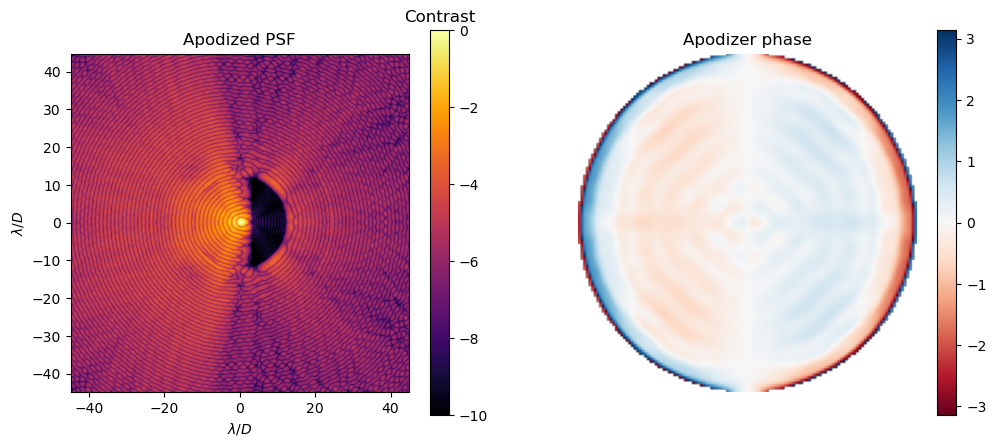

In [4]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
show_psf(app_psf,title='Apodized PSF',vmin=-10,ext=0.7)
plt.subplot(1,2,2)
plot_masked_array(app_phase[~cmask],mask=cmask)
plt.title('Apodizer phase')

Text(0.5, 1.0, 'SLM phase')

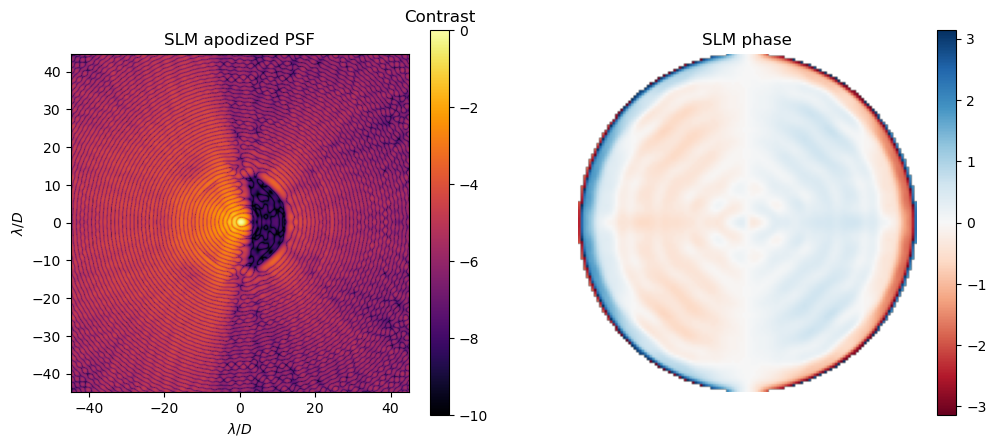

In [5]:
bit = 8
dphase = app_phase.max()-app_phase.min()
step = dphase/2**bit
slm_phase = xp.round(app_phase/step)*step

slm_psf = calc_psf(pupil*xp.exp(1j*slm_phase,dtype=xp.complex64))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
show_psf(slm_psf,title='SLM apodized PSF',vmin=-10,ext=0.7)
plt.subplot(1,2,2)
plot_masked_array(slm_phase[~cmask],mask=cmask)
plt.title('SLM phase')

Text(0.5, 1.0, 'SLM phase')

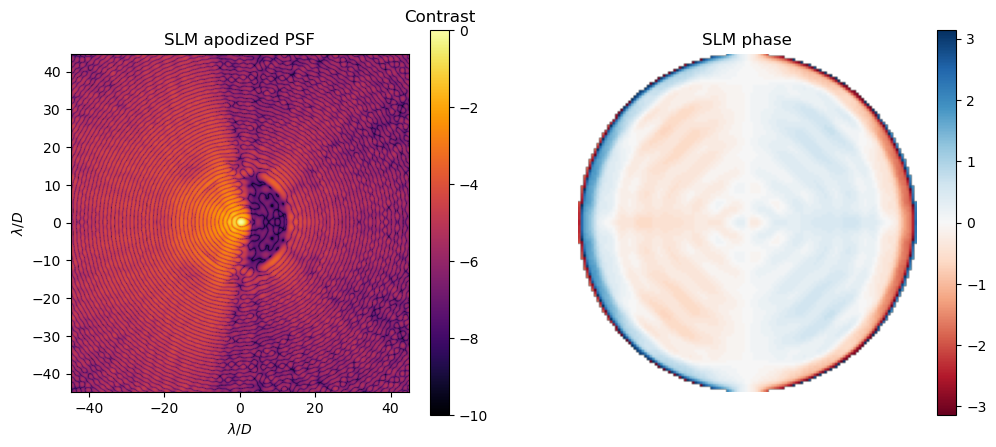

In [10]:
bit = 6
dphase = app_phase.max()-app_phase.min()
step = dphase/2**bit
slm6_phase = xp.round(app_phase/step)*step

slm6_psf = calc_psf(pupil*xp.exp(1j*slm6_phase,dtype=xp.complex64))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
show_psf(slm6_psf,title='SLM apodized PSF',vmin=-10,ext=0.7)
plt.subplot(1,2,2)
plot_masked_array(slm6_phase[~cmask],mask=cmask)
plt.title('SLM phase')

Text(0.5, 1.0, 'SLM phase')

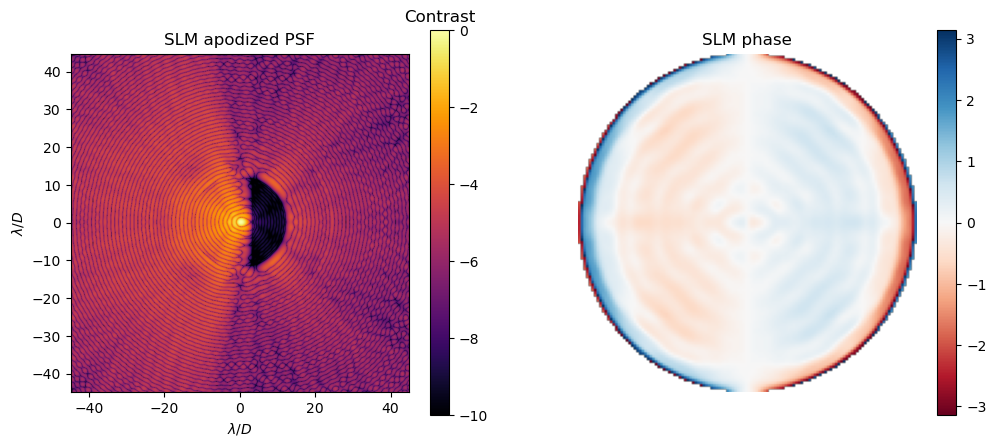

In [11]:
bit = 12
dphase = app_phase.max()-app_phase.min()
step = dphase/2**bit
slm12_phase = xp.round(app_phase/step)*step

slm12_psf = calc_psf(pupil*xp.exp(1j*slm12_phase,dtype=xp.complex64))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
show_psf(slm12_psf,title='SLM apodized PSF',vmin=-10,ext=0.7)
plt.subplot(1,2,2)
plot_masked_array(slm12_phase[~cmask],mask=cmask)
plt.title('SLM phase')

Text(0.5, 0, '$\\lambda/D$')

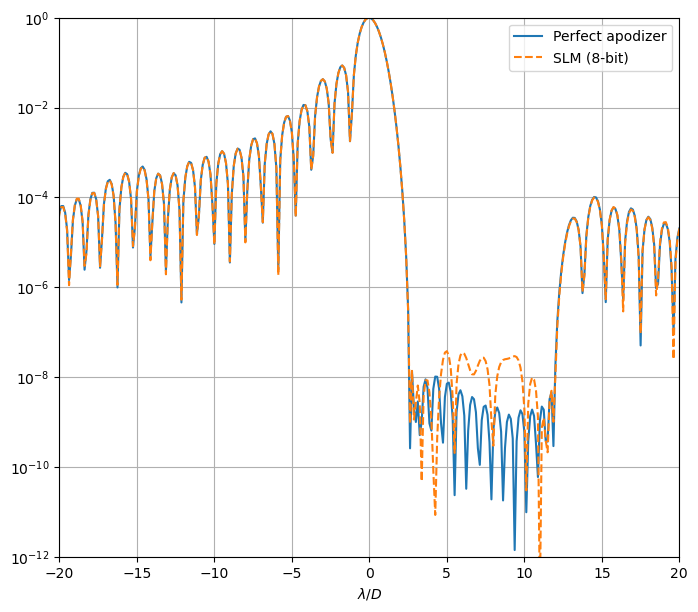

In [13]:
H,W = app_psf.shape
psf_oversampling = 8

plt.figure(figsize=(8,7))
plt.plot(xp.asnumpy(xp.arange(W)-W/2)/psf_oversampling,xp.asnumpy(app_psf[H/2,:]/xp.max(app_psf)),label='Perfect apodizer')
# plt.plot(xp.asnumpy(xp.arange(W)-W/2)/psf_oversampling,xp.asnumpy(slm6_psf[H/2,:]/xp.max(app_psf)),'--',label='SLM (6-bit)')
plt.plot(xp.asnumpy(xp.arange(W)-W/2)/psf_oversampling,xp.asnumpy(slm_psf[H/2,:]/xp.max(app_psf)),'--',label='SLM (8-bit)')
# plt.plot(xp.asnumpy(xp.arange(W)-W/2)/psf_oversampling,xp.asnumpy(slm12_psf[H/2,:]/xp.max(app_psf)),'--',label='SLM (12-bit)')
plt.legend()
plt.yscale('log')
plt.grid()
plt.xlim([-20,20])
plt.ylim([1e-12,1])
plt.xlabel(r'$\lambda/D$')